# 01 — EDA & Conditional Distributions: SPX returns vs log(VIX) (21-day windows)

**Goal.** Apply textbook EDA / conditional-probability techniques to the
S&P 500 and the VIX, sampled at a **21-trading-day** (monthly-ish) frequency.
Daily noise was overwhelming the signal; resampling to 21-day windows gives a
cleaner picture of how SPX returns relate to the volatility regime.

**Data.** 20 years of daily closes of `^GSPC` (S&P 500) and `^VIX` (CBOE VIX)
from yfinance, aggregated into non-overlapping 21-trading-day blocks:
- y = SPX log return over the block (sum of daily log returns)
- x = log of mean VIX over the same block

VIX is heavily right-skewed; the log transform compresses the panic tail and
puts the x-axis on a percentage-scale (one unit ≈ e-fold change in vol).

In [15]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = {
    'primary':   '#1b9e77',  # teal
    'secondary': '#7570b3',  # purple
    'tertiary':  '#d95f02',  # orange
    'accent':    '#e7298a',  # magenta
    'neutral':   '#666666',  # dark grey
    'bg':        '#f7f7f7',  # very light grey
}

plt.rcParams.update({
    'figure.figsize':    (9, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'legend.frameon':    False,
})

## 1. Load 10 years of daily SPX and VIX

In [16]:
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=20)

raw = yf.download(['^GSPC', '^VIX'], start=start, end=end, auto_adjust=False, progress=False)['Close']
raw.columns = ['SPX', 'VIX']
raw = raw.dropna()

daily = pd.DataFrame(index=raw.index)
daily['SPX_logret'] = np.log(raw['SPX']).diff()
daily['VIX']        = raw['VIX']
daily = daily.dropna()

# Resample to 21-trading-day non-overlapping blocks
WINDOW = 21
block_id = np.arange(len(daily)) // WINDOW
df = pd.DataFrame({
    'SPX_logret': daily['SPX_logret'].groupby(block_id).sum(),
    'VIX':        daily['VIX'].groupby(block_id).mean(),
    'date_end':   daily.index.to_series().groupby(block_id).last().values,
})
df['VIX_log'] = np.log(df['VIX'])
df = df.set_index('date_end').iloc[:-1]

print(f'Daily obs: {len(daily):,}  →  21-day blocks: {len(df):,}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
df.head()

Daily obs: 5,029  →  21-day blocks: 239
Date range: 2006-06-05 → 2026-04-17


,SPX_logret,VIX,VIX_log
date_end,,,
2006-06-05,-0.036442,15.005238,2.708399
2006-07-05,0.004432,16.853333,2.824548
2006-08-03,0.007338,15.389048,2.733656
2006-09-01,0.023727,13.104762,2.572976
2006-10-03,0.017467,12.216190,2.502762


## 2. Marginal distributions

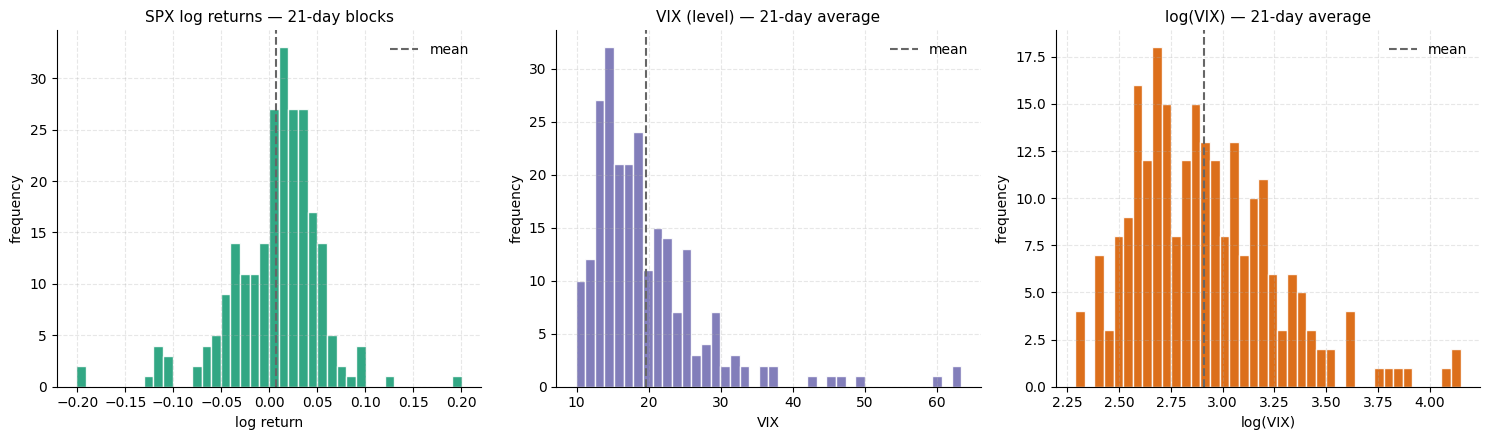

,mean,std,skew,kurt,min,max,count
SPX_logret,0.0071,0.0471,-0.8706,3.8953,-0.2011,0.2010,239
VIX,19.6039,8.2627,2.4754,8.8532,9.8433,63.3595,239
VIX_log,2.9102,0.3434,0.9081,1.2192,2.2868,4.1488,239


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df['SPX_logret'], bins=40, color=PALETTE['primary'],
             edgecolor='white', alpha=0.9)
axes[0].axvline(df['SPX_logret'].mean(), color=PALETTE['neutral'], linestyle='--', label='mean')
axes[0].set_title('SPX log returns — 21-day blocks')
axes[0].set_xlabel('log return'); axes[0].set_ylabel('frequency'); axes[0].legend()

axes[1].hist(df['VIX'], bins=40, color=PALETTE['secondary'],
             edgecolor='white', alpha=0.9)
axes[1].axvline(df['VIX'].mean(), color=PALETTE['neutral'], linestyle='--', label='mean')
axes[1].set_title('VIX (level) — 21-day average')
axes[1].set_xlabel('VIX'); axes[1].set_ylabel('frequency'); axes[1].legend()

axes[2].hist(df['VIX_log'], bins=40, color=PALETTE['tertiary'],
             edgecolor='white', alpha=0.9)
axes[2].axvline(df['VIX_log'].mean(), color=PALETTE['neutral'], linestyle='--', label='mean')
axes[2].set_title('log(VIX) — 21-day average')
axes[2].set_xlabel('log(VIX)'); axes[2].set_ylabel('frequency'); axes[2].legend()

plt.tight_layout()
plt.show()

summary = df.agg(['mean', 'std', 'skew', 'kurt', 'min', 'max']).T
summary['count'] = len(df)
summary.round(4)

## 3. Joint relationship — scatter

Each dot is one 21-trading-day block: y = SPX log return over the block,
x = log of mean VIX over the block. Using log(VIX) puts the x-axis on a
percentage-scale and makes the linear relationship more visible than the
raw level (which is dragged sideways by panic-day outliers).

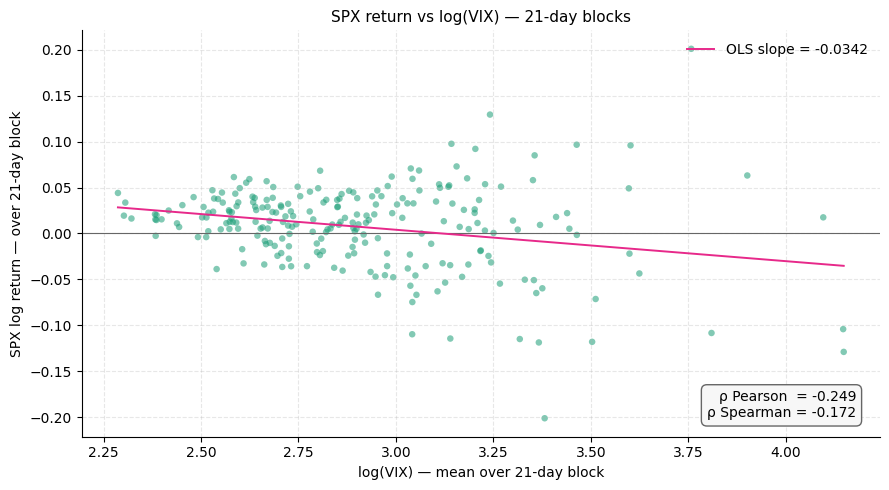

In [18]:
from scipy.stats import spearmanr

fig, ax = plt.subplots()
x = df['VIX_log'].values
y = df['SPX_logret'].values
ax.scatter(x, y, color=PALETTE['primary'], alpha=0.55, s=22, edgecolor='none')
ax.axhline(0, color=PALETTE['neutral'], linewidth=0.8)

b1, b0 = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
ax.plot(xx, b0 + b1 * xx, color=PALETTE['accent'], linewidth=1.4,
        label=f'OLS slope = {b1:+.4f}')

rho_p = np.corrcoef(x, y)[0, 1]
rho_s = spearmanr(x, y).correlation
ax.text(0.97, 0.04,
        f'ρ Pearson  = {rho_p:+.3f}\nρ Spearman = {rho_s:+.3f}',
        transform=ax.transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=PALETTE['bg'], edgecolor=PALETTE['neutral']))

ax.set_xlabel('log(VIX) — mean over 21-day block')
ax.set_ylabel('SPX log return — over 21-day block')
ax.set_title('SPX return vs log(VIX) — 21-day blocks')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Bin VIX into low / mid / high regimes

Splits at the **25th** and **75th** percentiles of the in-sample VIX.
We treat each bin as a discrete "event" $V \in \{\text{low, mid, high}\}$ and
study the conditional distribution $P(\text{SPX return} \mid V)$.

In [19]:
q25, q75 = df['VIX_log'].quantile([0.25, 0.75])

def bin_vix(v):
    if v <= q25: return 'low'
    if v <= q75: return 'mid'
    return 'high'

df['VIX_bin'] = df['VIX_log'].apply(bin_vix)
df['VIX_bin'] = pd.Categorical(df['VIX_bin'], categories=['low', 'mid', 'high'], ordered=True)

print(f'log(VIX) bin thresholds: 25th pct = {q25:.3f}  (VIX = {np.exp(q25):.2f})')
print(f'                         75th pct = {q75:.3f}  (VIX = {np.exp(q75):.2f})\n')

stats = df.groupby('VIX_bin', observed=False)['SPX_logret'].agg(
    n='count', mean='mean', std='std', skew='skew',
    p05=lambda x: x.quantile(0.05), p50='median', p95=lambda x: x.quantile(0.95),
    pos_share=lambda x: (x > 0).mean(),
)
stats.round(4)

log(VIX) bin thresholds: 25th pct = 2.663  (VIX = 14.34)
                         75th pct = 3.121  (VIX = 22.68)



,n,mean,std,skew,p05,p50,p95,pos_share
VIX_bin,,,,,,,,
low,60,0.0199,0.0208,-0.6121,-0.0179,0.0205,0.0496,0.8667
mid,119,0.0067,0.0349,-0.5468,-0.0486,0.0100,0.0538,0.6134
high,60,-0.0051,0.0760,-0.2774,-0.1191,0.0049,0.0966,0.5667


## 5. Conditional distributions — violin plot

$P(\text{SPX log return} \mid \text{VIX bin})$ side-by-side. The means stay
near zero; what changes across regimes is the **dispersion** and the **lower
tail** — the visual core of why VIX is treated as a fear gauge.

/var/folders/gd/46g2hsl52yx0m_gmp4131fdh0000gp/T/ipykernel_46018/2716095479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


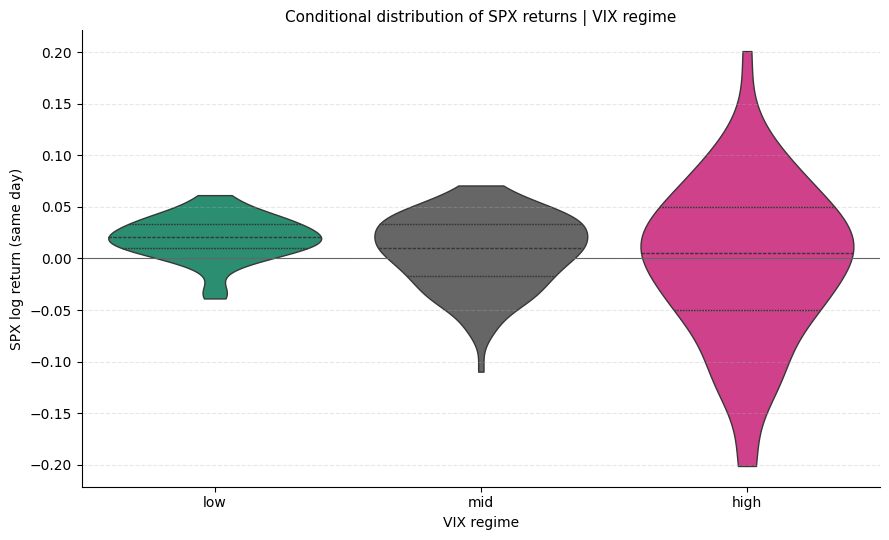

In [20]:
bin_colors = {
    'low':  PALETTE['primary'],
    'mid':  PALETTE['neutral'],
    'high': PALETTE['accent'],
}

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(
    data=df, x='VIX_bin', y='SPX_logret', order=['low', 'mid', 'high'],
    palette=[bin_colors[b] for b in ['low', 'mid', 'high']],
    inner='quartile', linewidth=1.0, cut=0, ax=ax,
)
ax.axhline(0, color=PALETTE['neutral'], linewidth=0.8)
ax.set_xlabel('VIX regime')
ax.set_ylabel('SPX log return (same day)')
ax.set_title('Conditional distribution of SPX returns | VIX regime')
plt.tight_layout()
plt.show()

## 6. Reading the picture — conditional probabilities

Some elementary conditional probabilities the bins make easy:

- $P(\text{SPX} < 0 \mid V)$ — chance of a down day in each regime
- $P(\text{SPX} < -2\% \mid V)$ — chance of a tail-loss day
- $P(\text{SPX} > +2\% \mid V)$ — chance of a tail-gain day

In [21]:
events = {
    'P(ret < 0  | V)':   lambda x: (x < 0).mean(),
    'P(ret < -2% | V)':  lambda x: (x < -0.02).mean(),
    'P(ret > +2% | V)':  lambda x: (x >  0.02).mean(),
}
cond_prob = df.groupby('VIX_bin', observed=False)['SPX_logret'].agg(**events)
cond_prob.round(3)

,P(ret < 0 | V),P(ret < -2% | V),P(ret > +2% | V)
VIX_bin,,,
low,0.133,0.050,0.500
mid,0.387,0.244,0.395
high,0.433,0.383,0.367
